## Downloading dataset from kaggle-CLI

In [1]:
%pip install kaggle

Note: you may need to restart the kernel to use updated packages.


In [2]:
#!/bin/bash
!kaggle datasets download -d rjmanoj/credit-card-customer-churn-prediction -p ~/Desktop/Nural_Network/Data

Dataset URL: https://www.kaggle.com/datasets/rjmanoj/credit-card-customer-churn-prediction
License(s): unknown
100%|█████████████████████████████████████████| 262k/262k [00:00<00:00, 277kB/s]



In [4]:
# extracting the compessed Dataset
from zipfile import ZipFile
from pathlib import Path

zip_path = Path.home() / "Desktop/Nural_Network/Data/credit-card-customer-churn-prediction.zip"
extract_dir = Path.home() / "Desktop/Nural_Network/Data/credit-card-customer-churn-prediction"

with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Dataset extracted to:", extract_dir)

Dataset extracted to: /home/midori/Desktop/Nural_Network/Data/credit-card-customer-churn-prediction


## Imports

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


## Data-Loading

In [51]:
df = pd.read_csv('../../../Data/credit-card-customer-churn-prediction/Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Data-Analysis

In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [19]:
df.groupby('Exited').size()

Exited
0    7963
1    2037
dtype: int64

In [ ]:
df.groupby('Geography').size()
# same as df['Grography].value_count()

Geography
France     5014
Germany    2509
Spain      2477
dtype: int64

In [3]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

## Data-Preprocessing

In [53]:
# remove first three unnecessary columns
df = df.drop(columns=['RowNumber','CustomerId','Surname'])
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [54]:
# convert caterogical columns into numerical(0/1)
# to turn all the data into numerical before feeding into any ML/DL algo
df = pd.get_dummies(df, columns=['Geography','Gender'], drop_first=True)
# It removes one dummy column per category.
# If both Germany=0 and Spain=0 → it MUST be France
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [55]:
X = df.drop(columns=['Exited'])
Y = df.drop(columns=X)
Y

,Exited
0,1
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,1


In [56]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,
                                                 test_size=0.2,
                                                 random_state=33)

In [17]:
df.shape

(10000, 12)

In [14]:
X.shape

(10000, 11)

In [12]:
X_train.shape

(8000, 11)

In [57]:
scalar = StandardScaler()

In [58]:
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

In [59]:
import joblib

In [60]:
joblib.dump(scalar,'scalar.pkl')

['scalar.pkl']

## ANN training

In [61]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Input

In [62]:
model = Sequential([
    Input(shape=(11,)),
    Dense(8, activation='relu'),
    Dense(5, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [63]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 8)              │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │            45 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 147 (588.00 B)

 Trainable params: 147 (588.00 B)

 Non-trainable params: 0 (0.00 B)

In [64]:
model.compile(loss='binary_crossentropy', 
              optimizer='Adam', 
              metrics=['accuracy'])

In [65]:
history = model.fit(X_train_scaled,Y_train, epochs=100, validation_split=0.2)

Epoch 1/100


200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6523 - loss: 0.6365 - val_accuracy: 0.7794 - val_loss: 0.5664
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7994 - loss: 0.4938 - val_accuracy: 0.7800 - val_loss: 0.4920
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8005 - loss: 0.4475 - val_accuracy: 0.7781 - val_loss: 0.4670
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8028 - loss: 0.4315 - val_accuracy: 0.7788 - val_loss: 0.4570
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8084 - loss: 0.4221 - val_accuracy: 0.7875 - val_loss: 0.4498
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8163 - loss: 0.4132 - val_accuracy: 0.8069 - val_loss: 0.4381
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8245 - loss: 0.4035 - val_accuracy: 0.8213 - val_loss: 0.4255
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8348 - loss: 0.3923 - val_accuracy: 0.8325

In [66]:
model.save('ann_model.keras')

## Prediction

In [67]:
from tensorflow import keras

In [68]:
model = keras.models.load_model('ann_model.keras')

In [69]:
model.layers[0].get_weights()
# input ---> hidden layers 1
# 11*8 = 88 weights
# 8 bias
# 88+8 = 96 tainable parameters

[array([[-0.02944011, -0.08794061,  0.0373952 , -0.0241558 ,  0.23348519,
         -0.49156567,  0.00305467,  0.16914815],
        [ 0.8040697 , -0.18716583,  0.19224659, -0.7287665 , -0.19191992,
          0.16460793, -0.24544549, -0.34543112],
        [ 0.316344  , -0.572324  ,  0.12845081,  0.02437572,  0.09530536,
          0.23647436, -0.10083571, -0.05257382],
        [-0.11206095, -0.05729299,  0.01512716, -0.01975659, -0.39028043,
          0.14173208,  0.20181862, -0.8411889 ],
        [-0.09198384, -0.00543029, -0.6385821 ,  0.11758966,  0.40163705,
          0.31131423,  1.380623  , -1.068081  ],
        [ 0.2637041 , -0.4324776 ,  0.1431333 ,  0.0380505 , -0.05571558,
          0.14152619, -0.18235908, -0.01449461],
        [ 0.9255682 ,  0.46100768, -0.5961583 , -0.22254924,  0.29005235,
         -0.45203313,  0.0100845 ,  0.07427938],
        [ 0.05033377, -0.3148033 , -0.1402433 , -0.03062508,  0.02342809,
          0.79864323, -0.12525421, -0.04814542],
        [-0.1469

In [70]:
model.layers[1].get_weights()
# hidden1 ---> hidden2 layers 
# 8*5 = 40 weights
# 5 bias
# 40+5 = 45 tainable parameters

[array([[-0.24474691, -0.06471088,  0.3375025 ,  0.84518045, -0.5901967 ],
        [ 0.34770527,  0.07655925, -0.6770423 ,  0.37672052,  0.54450744],
        [ 0.27343965,  0.04564707, -0.72663546, -0.213451  , -0.60475624],
        [-0.74092436, -1.1085839 ,  0.27105126,  0.7617555 ,  0.14266266],
        [-0.01779503,  0.17058173,  0.22610745,  0.7309135 ,  0.9415765 ],
        [ 0.08864136,  0.7194296 , -1.1133041 ,  0.28173774,  0.10273333],
        [-1.6633056 ,  1.3555205 , -0.23047574, -0.63914704, -0.05138084],
        [-0.10670014,  0.94198334, -2.3998723 , -0.13735068, -0.7040616 ]],
       dtype=float32),
 array([0.41305068, 0.07076518, 0.10826225, 0.37538135, 0.2960107 ],
       dtype=float32)]

In [71]:
model.layers[2].get_weights()
# hidden1 ---> hidden2 layers 
# 5*1 = 5 weights
# 1 bias
# 5+1 = 6 tainable parameters

# 96+45+6 = 147 trainable parameters in each of the 10 epoches in forward propagation

[array([[ 1.7087318 ],
        [ 1.3492934 ],
        [ 1.0418478 ],
        [-1.0270008 ],
        [-0.62600297]], dtype=float32),
 array([-0.0847801], dtype=float32)]

In [72]:
y_log = model.predict(X_test_scaled)
y_log

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


array([[0.00602237],
       [0.1275787 ],
       [0.1672043 ],
       ...,
       [0.00575705],
       [0.04780862],
       [0.07539747]], shape=(2000, 1), dtype=float32)

In [73]:
y_pred = np.where(y_log>0.5, 1,0)
y_pred

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]], shape=(2000, 1))

In [74]:
from sklearn.metrics import accuracy_score

In [75]:
accuracy_score(y_pred,Y_test)

0.8575

## Graphs

In [76]:
import matplotlib.pyplot as plt

In [77]:
history.history
# loss, accuracy, val_loss, val_accuracy

{'accuracy': [0.65234375,
  0.7993749976158142,
  0.8004687428474426,
  0.8028125166893005,
  0.8084375262260437,
  0.8162500262260437,
  0.8245312571525574,
  0.8348437547683716,
  0.8443750143051147,
  0.8478124737739563,
  0.852343738079071,
  0.8582812547683716,
  0.8590624928474426,
  0.860156238079071,
  0.8603125214576721,
  0.8595312237739563,
  0.8603125214576721,
  0.8610937595367432,
  0.8596875071525574,
  0.8606250286102295,
  0.8623437285423279,
  0.860156238079071,
  0.86328125,
  0.862500011920929,
  0.8620312213897705,
  0.8623437285423279,
  0.8637499809265137,
  0.862500011920929,
  0.86328125,
  0.8634374737739563,
  0.8609374761581421,
  0.8618749976158142,
  0.8620312213897705,
  0.8637499809265137,
  0.8637499809265137,
  0.8637499809265137,
  0.864062488079071,
  0.8617187738418579,
  0.8642187714576721,
  0.8634374737739563,
  0.8620312213897705,
  0.8631250262260437,
  0.8650000095367432,
  0.8623437285423279,
  0.8634374737739563,
  0.8645312786102295,
  0.86

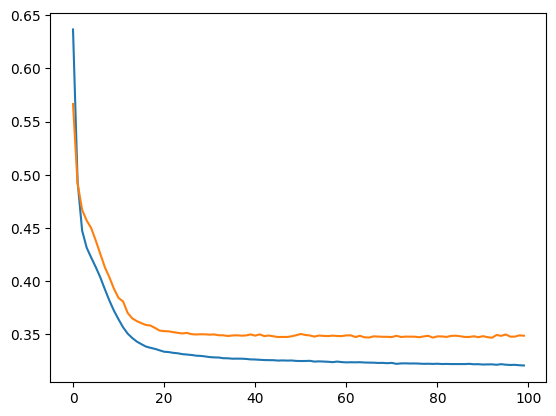

In [79]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

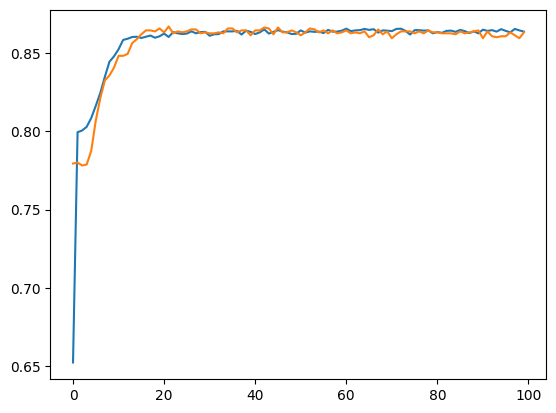

In [81]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])